In [1]:
# Custom tools
from modules.instance import Instance
from strategies.config import Config 
instance = Instance()
global_vars = Config()

# Modules (charts and mean reversion)
from modules.analyzer import TrendAnalyzer
from strategies.strategies import Strategy

Enter symbol:HIO
Action: BUY, Price: 0.14000000059604645, Date: 37, Position Size: 178571.42781116525
Action: SELL, Price: 0.125, Date: 38, Position Size: 178571.42781116525
Action: BUY, Price: 0.125, Date: 39, Position Size: 200000.0
Action: SELL, Price: 0.11999999731779099, Date: 41, Position Size: 200000.0
Action: BUY, Price: 0.10499999672174454, Date: 42, Position Size: 238095.2455289242
Action: SELL, Price: 0.10000000149011612, Date: 43, Position Size: 238095.2455289242
Action: BUY, Price: 0.07400000095367432, Date: 92, Position Size: 337837.8334839559
Action: SELL, Price: 0.07800000160932541, Date: 94, Position Size: 337837.8334839559
Action: BUY, Price: 0.1599999964237213, Date: 173, Position Size: 156250.00349245974
Action: SELL, Price: 0.1899999976158142, Date: 174, Position Size: 156250.00349245974
Action: BUY, Price: 0.4300000071525574, Date: 249, Position Size: 58139.53391663639
Action: SELL, Price: 0.38499999046325684, Date: 250, Position Size: 58139.53391663639
Action: BU

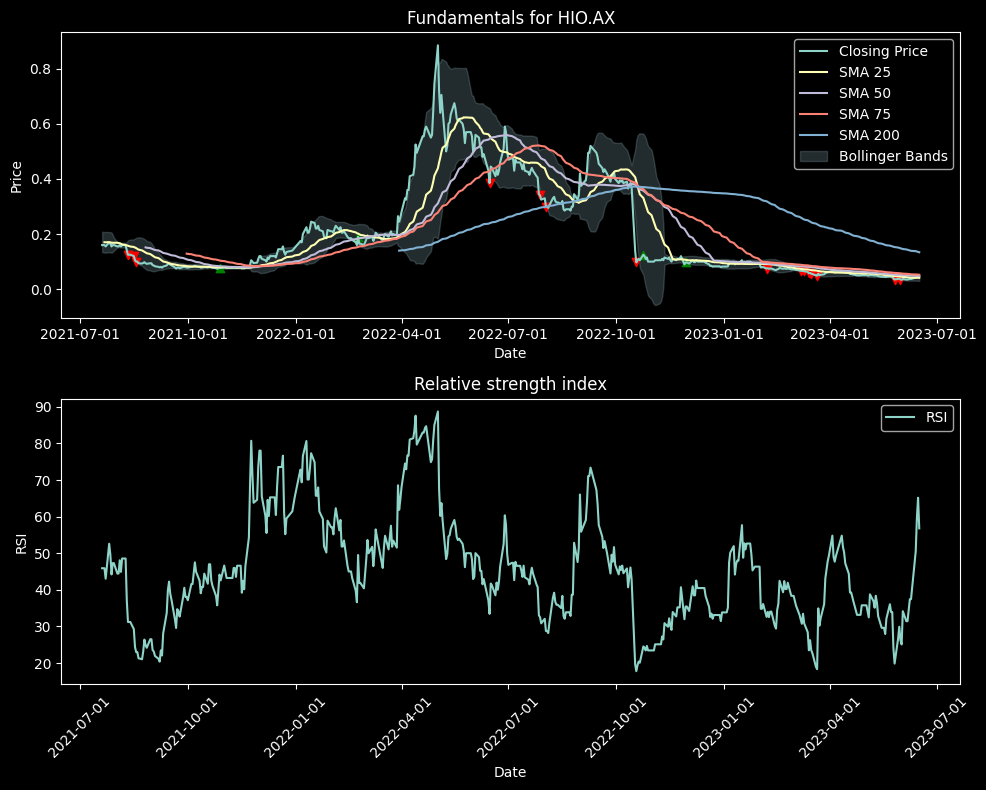

In [2]:
def main():
    # Get a basic ticker input
    ticker = input("Enter symbol:")
    table_name = ticker+'.AX' #append market suffix to match table we're asking for

    # Return a dataframe with basic T/A like BB_UPPER, RSI, SMA etc
    data = instance.datastore.get_table_data(table_name)
    
    allocated_capital = global_vars.total_funds # use the 100k from our global vars
    dca_entry = 0.25 # set 1/4 rule per dollar cost buy in 
    dca_exit = 1.0 # sell off 100%
     
    # Run a strategy and add trade/position date/signal columns to the dataframe
    data = Strategy.mean_reversion_strategy(
        data, 
        allocated_capital=allocated_capital, 
        dca_entry=dca_entry, 
        dca_exit=dca_exit)

    # init analyser with our data
    analyzer = TrendAnalyzer(table_name, data)
    
    # Generate a basic fundamentals chart (auto filters to 90 days, doesn't require orders, RSI output is option)
    analyzer.fundamentals_chart(filter=700, RSI = True, orders = True)

if __name__ == '__main__':
    main()